In [9]:
import numpy as np
import pandas as pd
import secrets
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.neural_network import MLPRegressor
import torch
import torch.nn as nn
import torch.optim as optim




# Generate a seed for rng

In [2]:
secrets.randbits(128)

225879665056570560972989296170714704228

In [2]:
rng = np.random.default_rng(225879665056570560972989296170714704228)


In [3]:
x0=[1]*1000
x1=rng.uniform(low=0, high=13, size=1000)
X = np.column_stack((x0, x1))

In [4]:
print(X)

[[ 1.         11.47094748]
 [ 1.          5.79488128]
 [ 1.         10.22777725]
 ...
 [ 1.          7.90275988]
 [ 1.         12.97058114]
 [ 1.          4.18695325]]


# Normally-distributed Errors

In [5]:
error=rng.normal(loc=0,scale=1,size=1000)

In [6]:
beta = np.array([[5], [1]])

In [7]:
y = (X @ beta).flatten() + error


In [8]:
print(y)

[17.25889499 10.19609461 13.08967677 15.23527036  7.28831389  6.89419217
 13.55717087 10.66259138 18.74330144  5.67567073 16.44849576 11.35011133
  6.7787728   7.32962503 12.18379613 14.0254759   9.8604569  14.5330762
  8.13563825 16.76812829 15.79178814  6.41330191 10.42534126  7.81670018
  5.82378633 15.99759489 18.69556591  7.52058705  6.29123091 13.550541
 10.02615877 13.99215065 10.44939062  8.21279625  9.77160741 13.27121438
 11.4916045  14.3439179  12.43857134  6.203142    7.19653641 14.94799388
  7.29646267 14.83268849 14.72100453 12.46812625 11.74908685  7.22069128
 14.69341876 15.58623523 14.65246568  8.75818606  5.65933522 16.03107422
  9.73247672  6.78163768  8.03208368 15.64057935  6.80804022 11.6838127
 10.80457068  9.9283759  10.55841085 17.16903466 15.04485212 15.63708642
  6.51509968  7.67554154  8.40015777 16.34862409  8.77886351  7.30290071
  7.186822    9.41629192  6.3700683  15.77002809  8.17580759  4.61635861
 11.14270012 11.15329467 15.07797799 10.0893946  13.473

In [9]:
df = pd.DataFrame({
    'x1': x1,
    'y': y
})

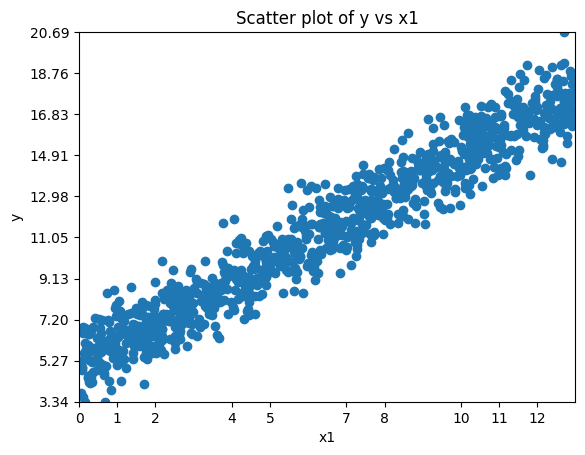

In [10]:
fig, ax = plt.subplots()

# Basic scatter plot
ax.scatter(x1, y)

# Set sensible limits based on data
ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(y.min(), y.max())

# Optional: set custom ticks if you want them
ax.set_xticks(np.linspace(x1.min(), x1.max(), num=10, dtype=int))
ax.set_yticks(np.linspace(y.min(), y.max(), num=10))

plt.xlabel("x1")
plt.ylabel("y")
plt.title("Scatter plot of y vs x1")

plt.show()

In [11]:
x1=x1.reshape((-1, 1))

In [12]:
model = LinearRegression(fit_intercept=True).fit(x1, y)

In [13]:
model.score(x1, y)

0.9321887771020673

In [14]:
print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

intercept: 5.106098928213101
slope: [0.97738307]


In [15]:
model2 = sm.OLS(y, X)

In [16]:
results = model2.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.372e+04
Date:                Wed, 04 Jun 2025   Prob (F-statistic):               0.00
Time:                        21:11:56   Log-Likelihood:                -1417.6
No. Observations:                1000   AIC:                             2839.
Df Residuals:                     998   BIC:                             2849.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1061      0.062     82.463      0.0

In [20]:
model = MLPRegressor(hidden_layer_sizes=(),
                     activation='identity',
                     solver='lbfgs', 
                     max_iter=1000,
                     random_state=0)

model.fit(x1, y)

MLPRegressor(activation='identity', hidden_layer_sizes=(), max_iter=1000,
             random_state=0, solver='lbfgs')

$y=w*x+b$

In [21]:
print("Weights:", model.coefs_[0].flatten())
print("Bias:", model.intercepts_[0][0])

Weights: [0.97738297]
Bias: 5.106099237729979


In [17]:
X_tensor = torch.tensor(x1.reshape(-1,1), dtype=torch.float32)
y_tensor = torch.tensor(y.reshape(-1,1), dtype=torch.float32)

In [18]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 1 input feature → 1 output

    def forward(self, x):
        return self.linear(x)

In [21]:
model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(10000):
    model.train()
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 268.8686
Epoch 20, Loss: 4.8156
Epoch 40, Loss: 4.1039
Epoch 60, Loss: 3.5249
Epoch 80, Loss: 3.0538
Epoch 100, Loss: 2.6706
Epoch 120, Loss: 2.3587
Epoch 140, Loss: 2.1050
Epoch 160, Loss: 1.8985
Epoch 180, Loss: 1.7305
Epoch 200, Loss: 1.5939
Epoch 220, Loss: 1.4827
Epoch 240, Loss: 1.3922
Epoch 260, Loss: 1.3186
Epoch 280, Loss: 1.2587
Epoch 300, Loss: 1.2100
Epoch 320, Loss: 1.1703
Epoch 340, Loss: 1.1381
Epoch 360, Loss: 1.1118
Epoch 380, Loss: 1.0905
Epoch 400, Loss: 1.0731
Epoch 420, Loss: 1.0590
Epoch 440, Loss: 1.0475
Epoch 460, Loss: 1.0381
Epoch 480, Loss: 1.0305
Epoch 500, Loss: 1.0243
Epoch 520, Loss: 1.0193
Epoch 540, Loss: 1.0151
Epoch 560, Loss: 1.0118
Epoch 580, Loss: 1.0091
Epoch 600, Loss: 1.0069
Epoch 620, Loss: 1.0051
Epoch 640, Loss: 1.0036
Epoch 660, Loss: 1.0024
Epoch 680, Loss: 1.0015
Epoch 700, Loss: 1.0007
Epoch 720, Loss: 1.0000
Epoch 740, Loss: 0.9995
Epoch 760, Loss: 0.9991
Epoch 780, Loss: 0.9988
Epoch 800, Loss: 0.9985
Epoch 820, Loss: 0.9

In [22]:
w = model.linear.weight.item()
b = model.linear.bias.item()

print(f"Learned weight: {w:.2f}")
print(f"Learned bias: {b:.2f}")

Learned weight: 0.98
Learned bias: 5.11
